In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sleap
import numpy as np
import datetime
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import ConnectionPatch
from pathlib import Path
from itertools import combinations
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare

In [2]:
from sleap_roots_training.evaluate import (main, 
                                           predictions_viz_from_sleap_files, 
                                           fetch_sweep_metrics, 
                                           get_sweep_ids_for_group_from_runs, 
                                           visualize_predictions_from_artifacts,
)

from sleap_roots_training import config

In [3]:
# Constants for W&B initialization
ENTITY_NAME = "eberrigan-salk-institute-for-biological-studies"
PROJECT_NAME = "sleap-roots"
REGISTRY = "sleap-roots-models"
JOB_TYPE = "evaluation"
EXPERIMENT_NAME = "20250717_plate_medicago_primary_sweep_receptive_field"

# Constants for artifact creation
DESCRIPTION = "14 DAG medicago primary root in plates with 8 nodes varying max stride [16, 32, 64, 128] and input scaling [0.15, 0.25, 0.35] sweep"
TAGS = ["plate", "medicago", "14DAG", "primary", "8nodes", "medicago14DAG", "2025-07-11", "receptive_field_sweep"]
COLLECTION_NAME = EXPERIMENT_NAME
CSV_PATH = "//multilab-na.ad.salk.edu/hpi_dev/users/eberrigan/SLEAP/20250717_plate_medicago_primary_sweep_receptive_field/train_test_splits.csv"
ARTIFACT_NAME = "plate_medicago_primary_receptive_field_sweep_evaluation"

# Model and group configuration
# https://wandb.ai/eberrigan-salk-institute-for-biological-studies/sleap-roots/groups
MODEL_GROUP = "20250717_plate_medicago_primary_sweep_receptive_field" # This is the group name for the sweep
TARGET_METRICS = ["dist_p50", "dist_p90", "dist_p95", "dist_p99", "dist_avg", "dist_std", "vis_prec", "vis_recall", "oks_map", "oks_mar"]

In [4]:
config.reset_config()

Configuration updated successfully at c:\repos\sleap-roots-training\sleap_roots_training\config.yaml.
Configuration has been reset to default values.


In [5]:
config.update_config(entity_name=ENTITY_NAME, project_name=PROJECT_NAME, registry=REGISTRY, experiment_name=EXPERIMENT_NAME)

Configuration updated successfully at c:\repos\sleap-roots-training\sleap_roots_training\config.yaml.
CONFIG updated to {'project_name': 'sleap-roots', 'entity_name': 'eberrigan-salk-institute-for-biological-studies', 'experiment_name': '20250717_plate_medicago_primary_sweep_receptive_field', 'registry': 'sleap-roots-models', 'collection_name': None, 'job_type': None}.


In [6]:
# Make directory for experiment
Path(EXPERIMENT_NAME).mkdir(exist_ok=True, parents=True)

In [7]:
datetime_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [8]:
# sweep_ids = get_sweep_ids_for_group_from_runs(group_name=MODEL_GROUP)
sweep_ids = [
'u8i829vf',
'xr294xqe',
'35l9xwmy', 
]

In [9]:
sweep_df = fetch_sweep_metrics(
    sweep_ids=sweep_ids,
    target_metrics=TARGET_METRICS,
    include_config=True,
)

In [10]:
sweep_df

,run_id,name,group,sweep_id,dist_p50,dist_p90,dist_p95,dist_p99,dist_avg,dist_std,...,config/name,config/model,config/outputs,config/filename,config/config_path,config/description,config/optimization,config/sleap_version,config/model.backbone.unet.max_stride,config/data.preprocessing.input_scaling
0,o9d5n4dz,winter-sweep-12,None,u8i829vf,3.521799,11.088073,21.605982,51.095684,6.078526,9.081717,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,128,0.35
1,ra2lh5df,dazzling-sweep-11,None,u8i829vf,4.437859,14.222200,45.725908,81.643952,9.661513,17.198053,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,64,0.35
2,v59mbsff,glad-sweep-10,None,u8i829vf,6.293790,34.495877,37.548135,100.384354,12.565228,17.044521,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,32,0.35
3,qhwd1vf0,honest-sweep-9,None,u8i829vf,3.507441,34.705419,49.441702,92.632148,11.974237,20.603517,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,16,0.35
4,b3ikbe8v,pious-sweep-8,None,u8i829vf,4.242812,10.846311,14.132829,25.714252,5.493401,5.308388,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,128,0.25
5,oo3kajuy,blooming-sweep-7,None,u8i829vf,5.359923,14.243487,23.255717,39.451828,7.117625,7.711180,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,64,0.25
6,ivr3ou2s,hearty-sweep-6,None,u8i829vf,4.089892,16.308747,23.925326,57.494016,7.275967,9.542897,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,32,0.25
7,b22k7rx2,fearless-sweep-5,None,u8i829vf,5.114410,59.297852,86.185469,105.902716,15.932916,25.970244,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,16,0.25
8,zky62msf,chocolate-sweep-4,None,u8i829vf,5.009109,14.271901,19.775227,39.159597,7.123793,8.171626,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,128,0.15
9,hjok9rs4,ancient-sweep-3,None,u8i829vf,4.963373,15.048461,19.718643,40.620188,7.128154,7.800440,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 

In [11]:
sweep_csv_path = Path(EXPERIMENT_NAME) / f"sweep_metrics_px_to_mm_WRONG{datetime_str}.csv"
sweep_df.to_csv(sweep_csv_path, index=False)
print(f"Sweep metrics saved to {sweep_csv_path}")

Sweep metrics saved to 20250717_plate_medicago_primary_sweep_receptive_field\sweep_metrics_px_to_mm_WRONG2025-07-21_09-45-22.csv


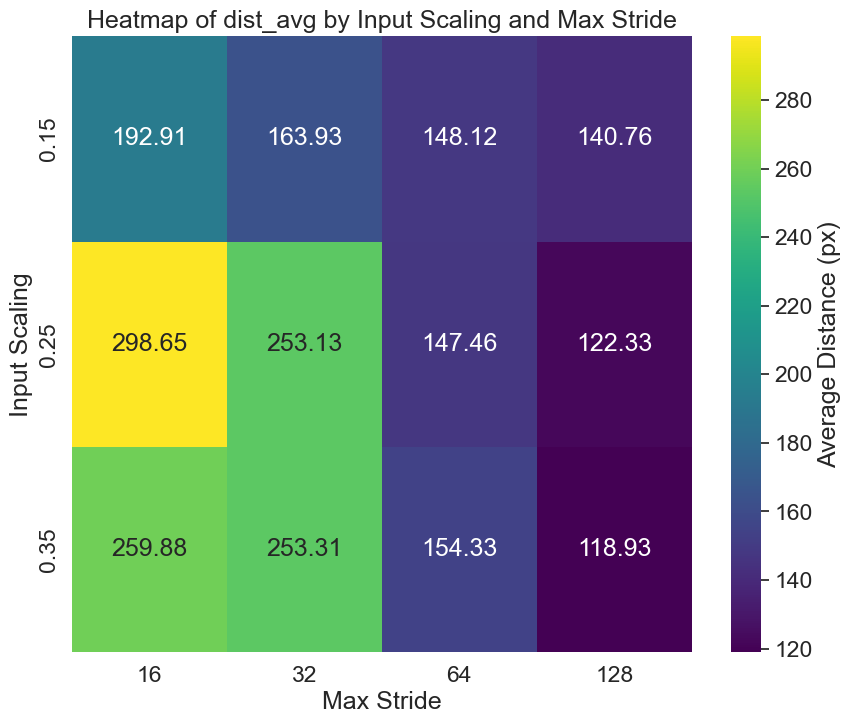

In [12]:
# heat map of error metrics
# x axis is config/model.backbone.unet.max_stride, y axis is config/data.preprocessing.input_scaling

# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}


plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# Create a heatmap of the sweep metrics
data = sweep_df.copy()
metric = "dist_avg"  # Change this to the metric you want to visualize

# Undo incorrect px to mm conversion
px_to_mm = 17
data[metric] = data[metric] * px_to_mm
# Pivot the DataFrame to create a heatmap format
data = data.pivot_table(
    index="config/data.preprocessing.input_scaling",
    columns="config/model.backbone.unet.max_stride",
    values="dist_avg"
)

plt.figure(figsize=(10, 8))
sns.heatmap(data, annot=True, fmt=".2f", cmap="viridis", 
            cbar_kws={"label": "Average Distance (px)"})
plt.title(f"Heatmap of {metric} by Input Scaling and Max Stride")

plt.xlabel("Max Stride")
plt.ylabel("Input Scaling")

# Save the heatmap
heatmap_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_heatmap_{metric}.png"
plt.savefig(heatmap_file_path, bbox_inches='tight')
plt.show()


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

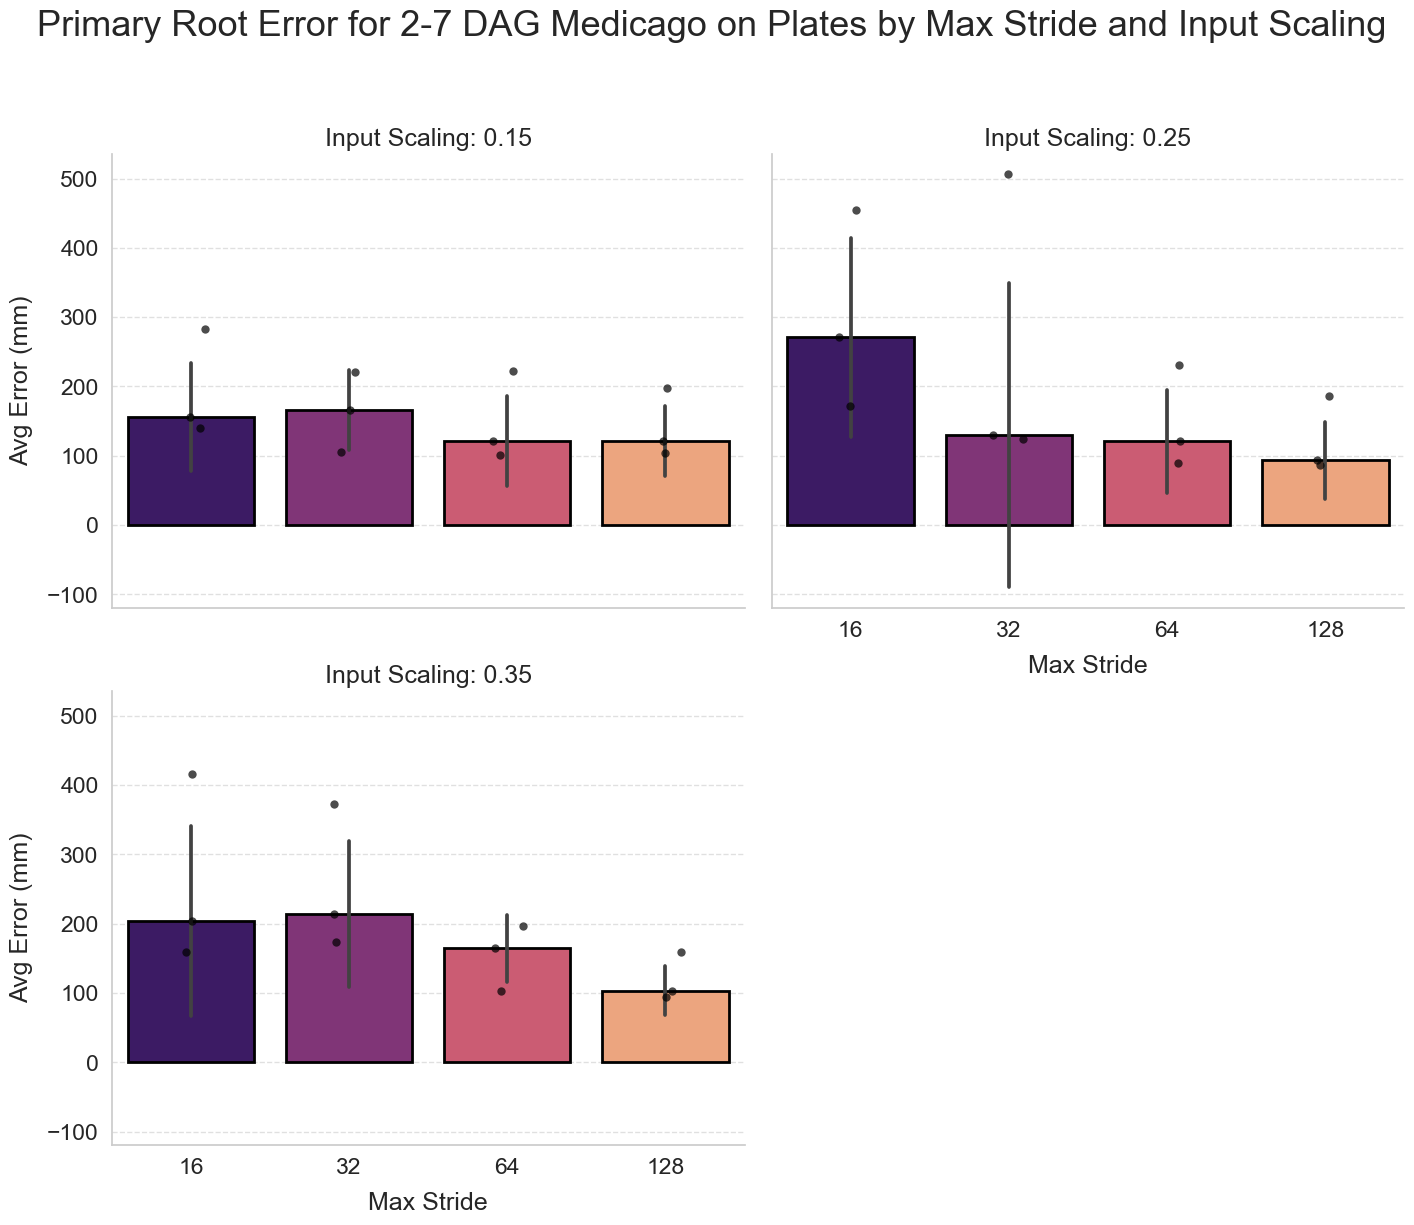

Plot saved to 20250717_plate_medicago_primary_sweep_receptive_field\2025-07-21_09-45-22_facet_grid_error_by_scaling_stride.png


In [13]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}

plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== PLOTTING ==========
data = sweep_df.copy()
metric = "dist_avg"
data[metric] = data[metric] * 17  # Undo px to mm conversion

# Create a FacetGrid of barplots
g = sns.FacetGrid(
    data=data,
    col="config/data.preprocessing.input_scaling",
    col_wrap=2,  # adjust if you want a different layout
    sharey=True,
    height=6,
    aspect=1.2
)

# Barplot: median + std
g.map_dataframe(
    sns.barplot,
    x="config/model.backbone.unet.max_stride",
    y=metric,
    estimator=np.median,
    errorbar="sd",
    palette="magma",
    edgecolor="black",
    linewidth=2
)

# Overlay raw points
g.map_dataframe(
    sns.stripplot,
    x="config/model.backbone.unet.max_stride",
    y=metric,
    color="black",
    size=6,
    alpha=0.7,
    jitter=True
)

# Adjustments
for ax in g.axes.flat:
    ax.set_xlabel("Max Stride", labelpad=10)
    ax.set_ylabel("Avg Error (mm)", labelpad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    sns.despine(ax=ax)

g.set_titles(col_template="Input Scaling: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Primary Root Error for 2-7 DAG Medicago on Plates by Max Stride and Input Scaling", fontsize=26, y=1.02)

# Save
plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_facet_grid_error_by_scaling_stride.png"
plot_file_path.parent.mkdir(parents=True, exist_ok=True)

g.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")

In [14]:
# selected_version = "000"
# model_name = f"{MODEL_GROUP}_v{selected_version}"


# visualize_predictions_from_artifacts(model_artifact_name=model_name,
#                                      test_artifact_name=model_name,
#                                      output_dir=Path(EXPERIMENT_NAME) / f"{datetime_str}_{model_name}_test_predictions",
#                                      num_frames=5,
#                                      overwrite=False,
# )


In [15]:
# === Initialize the W&B run ===
add_files_run = wandb.init(
    project=PROJECT_NAME,
    entity=ENTITY_NAME,
    job_type="add_files_to_artifact"
)

# === Create a new artifact ===
new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")
new_metrics_artifact.description = (
    f"Summary plots and metrics from {len(sweep_ids)} sweeps for experiment '{EXPERIMENT_NAME}'."
)
new_metrics_artifact.metadata.update({
    "source_sweep_ids": sweep_ids,
    "experiment_name": EXPERIMENT_NAME,
    "metrics": TARGET_METRICS,
    "generated_at": datetime_str,
})

# === Add plots and CSVs ===
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_heatmap_{metric}.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_facet_grid_error_by_scaling_stride.png").as_posix())
new_metrics_artifact.add_file(Path(sweep_csv_path).as_posix())

# === Add run references (optional) ===
api = wandb.Api()
for sweep_id in sweep_ids:
    sweep = api.sweep(f"{ENTITY_NAME}/{PROJECT_NAME}/{sweep_id}")
    for run in sweep.runs:
        if run.state != "finished":
            continue
        new_metrics_artifact.add_reference(run.url)

# === Log and finish ===
add_files_run.log_artifact(new_metrics_artifact)
add_files_run.finish()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: eberrigan (eberrigan-salk-institute-for-biological-studies). Use `wandb login --relogin` to force relogin


In [16]:
# # === Initialize the W&B run ===
# add_files_run = wandb.init(
#     project=PROJECT_NAME,
#     entity=ENTITY_NAME,
#     job_type="add_files_to_artifact"
# )

# # === Use existing artifact and download its contents ===
# # metrics_artifact = add_files_run.use_artifact(f"{ARTIFACT_NAME}:latest", type="metrics")
# # artifact_dir = Path(metrics_artifact.download())
# # print(f"Artifact downloaded to: {artifact_dir}")

# # === Create a new artifact ===
# new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")

# # === Add plots ===
# new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval.png").as_posix())
# new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version.png").as_posix())

# # === Add associated CSVs ===
# new_metrics_artifact.add_file((Path(label_csv_path)).as_posix())
# new_metrics_artifact.add_file((Path(sweep_csv_path)).as_posix())

# # === Add existing artifact contents ===
# # for file_path in artifact_dir.iterdir():
# #     new_metrics_artifact.add_file(file_path)

# # === Log and finish ===
# add_files_run.log_artifact(new_metrics_artifact)
# add_files_run.finish()